In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define raw data path
DATA_PATH = Path("../01_data/raw/data.csv")

# Read data
df = pd.read_csv(DATA_PATH)

# Preview data
df.head()

,shipped_date,sku,channel,qty,revenue,cost of good sold,MOQ order
0,1/1/2021,089A0E,ADS,190,5027.40,2926.00,56460
1,1/1/2021,089A0E,AWH,30,793.80,NaN,56460
2,1/1/2021,0FKFLA,AWH,780,32028.36,13104.00,427545
3,1/1/2021,0G8Z4M,AWH,85,1307.81,595.00,2516
4,1/1/2021,0NFJ14,FBM,38,2127.47,1723.25,18734


In [3]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

df.info()

Number of rows: 48,363
Number of columns: 7
<class 'pandas.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  str    
 1   sku                48363 non-null  str    
 2   channel            48363 non-null  str    
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 2.6 MB


In [4]:
df.columns

Index(['shipped_date', 'sku', 'channel', 'qty', 'revenue', 'cost of good sold',
       'MOQ order'],
      dtype='str')

In [5]:
df.head(10)

,shipped_date,sku,channel,qty,revenue,cost of good sold,MOQ order
0,1/1/2021,089A0E,ADS,190,5027.40,2926.00,56460
1,1/1/2021,089A0E,AWH,30,793.80,NaN,56460
2,1/1/2021,0FKFLA,AWH,780,32028.36,13104.00,427545
3,1/1/2021,0G8Z4M,AWH,85,1307.81,595.00,2516
4,1/1/2021,0NFJ14,FBM,38,2127.47,1723.25,18734
5,1/1/2021,0NFJ14,ADS,19,1063.73,744.53,18734
6,1/1/2021,11HSH1,FBM,150,7137.90,6209.97,96300
7,1/1/2021,13KMDL,AWH,444,31048.92,8018.64,158136
8,1/1/2021,17KYMH,ADS,690,40089.00,23667.00,203895
9,1/1/2021,17KYMH,AWH,138,8017.80,NaN,203895


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
cost of good sold,5052,10.446002
revenue,4264,8.816657
shipped_date,0,0.000000
channel,0,0.000000
sku,0,0.000000
qty,0,0.000000
MOQ order,0,0.000000


In [7]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 0


In [8]:
# Convert shipped_date to datetime
df["shipped_date"] = pd.to_datetime(df["shipped_date"])

# Check date range
print("Min date:", df["shipped_date"].min())
print("Max date:", df["shipped_date"].max())
print("Number of unique dates:", df["shipped_date"].nunique())

Min date: 2021-01-01 00:00:00
Max date: 2022-01-02 00:00:00
Number of unique dates: 184


In [9]:
print("Number of unique SKUs:", df["sku"].nunique())
print("Number of unique channels:", df["channel"].nunique())

print("\nChannels:")
print(df["channel"].value_counts())

Number of unique SKUs: 676
Number of unique channels: 6

Channels:
channel
AWH    24186
ADS    16289
FBA     4296
FBM     1500
ADI     1123
LAL      969
Name: count, dtype: int64


In [10]:
numeric_cols = ["qty", "revenue", "cost of good sold", "MOQ order"]

df[numeric_cols].describe()

,qty,revenue,cost of good sold,MOQ order
count,48363.000000,4.409900e+04,43311.000000,4.836300e+04
mean,260.299485,9.820125e+03,5868.778910,1.228741e+05
std,584.538111,2.361720e+04,11417.047281,3.168974e+05
min,-368.000000,-4.116450e+03,0.120000,1.000000e+01
25%,34.000000,1.483720e+03,1036.000000,1.093300e+04
50%,80.000000,3.697850e+03,2467.580000,3.769600e+04
75%,238.000000,9.708500e+03,6210.885000,1.019840e+05
max,18860.000000,1.084788e+06,425040.000000,3.407592e+06


In [11]:
print("Rows with qty < 0:", (df["qty"] < 0).sum())
print("Rows with qty = 0:", (df["qty"] == 0).sum())
print("Rows with qty > 0:", (df["qty"] > 0).sum())

Rows with qty < 0: 3
Rows with qty = 0: 203
Rows with qty > 0: 48157


In [12]:
daily_sales = (
    df.groupby("shipped_date", as_index=False)
    .agg(total_qty=("qty", "sum"))
)

daily_sales.head()

,shipped_date,total_qty
0,2021-01-01,92645
1,2021-01-03,70632
2,2021-01-05,56063
3,2021-01-07,18132
4,2021-01-09,75570


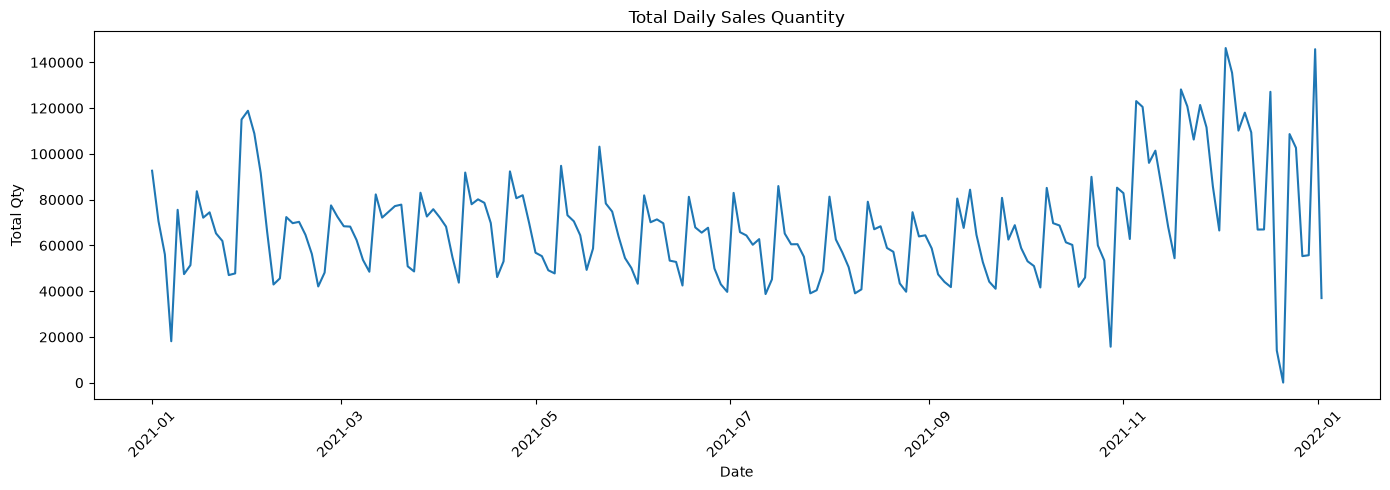

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales["shipped_date"], daily_sales["total_qty"])
plt.title("Total Daily Sales Quantity")
plt.xlabel("Date")
plt.ylabel("Total Qty")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
top_10_sku = (
    df.groupby("sku", as_index=False)
    .agg(total_qty=("qty", "sum"))
    .sort_values("total_qty", ascending=False)
    .head(10)
)

top_10_sku

,sku,total_qty
284,FJDJ6B,1135864
24,1JKADT,489020
99,4OCITK,454305
124,67LPLP,445832
586,V8SEQG,303472
592,VJK56C,235914
344,HVARMV,219384
228,BJ30D6,206584
625,XDYFFX,205983
647,Y6HWKQ,205000


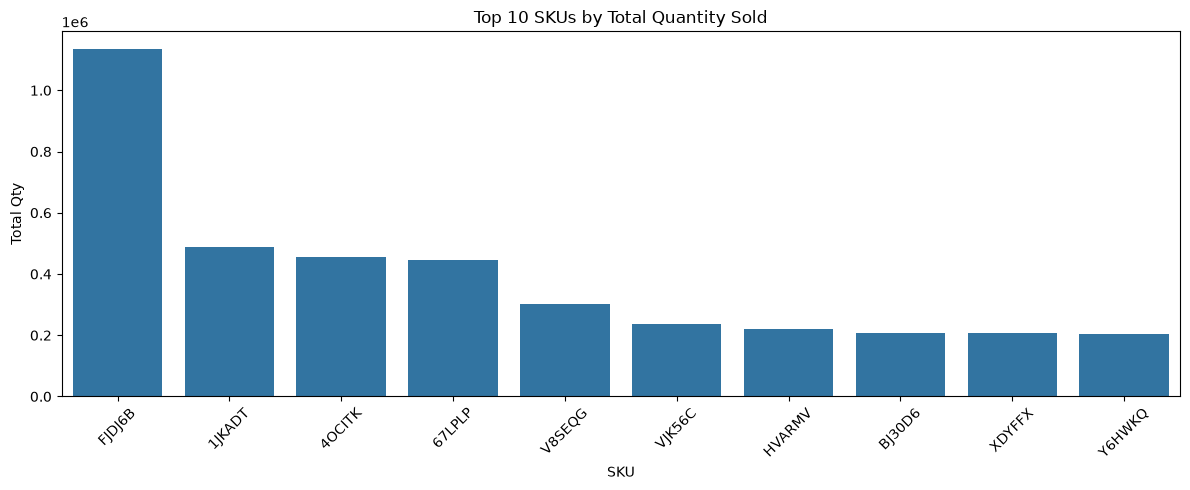

In [15]:
plt.figure(figsize=(12, 5))
sns.barplot(data=top_10_sku, x="sku", y="total_qty")
plt.title("Top 10 SKUs by Total Quantity Sold")
plt.xlabel("SKU")
plt.ylabel("Total Qty")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Create complete date range
full_date_range = pd.date_range(
    start=df["shipped_date"].min(),
    end=df["shipped_date"].max(),
    freq="D"
)

available_dates = pd.Series(df["shipped_date"].unique())
missing_dates = sorted(set(full_date_range) - set(available_dates))

print(f"Expected number of days: {len(full_date_range)}")
print(f"Available unique days: {df['shipped_date'].nunique()}")
print(f"Missing days: {len(missing_dates)}")

missing_dates[:10]

Expected number of days: 367
Available unique days: 184
Missing days: 183


[Timestamp('2021-01-02 00:00:00'),
 Timestamp('2021-01-04 00:00:00'),
 Timestamp('2021-01-06 00:00:00'),
 Timestamp('2021-01-08 00:00:00'),
 Timestamp('2021-01-10 00:00:00'),
 Timestamp('2021-01-12 00:00:00'),
 Timestamp('2021-01-14 00:00:00'),
 Timestamp('2021-01-16 00:00:00'),
 Timestamp('2021-01-18 00:00:00'),
 Timestamp('2021-01-20 00:00:00')]

In [17]:
daily_sales_sorted = daily_sales.sort_values("shipped_date").copy()
daily_sales_sorted["date_diff"] = daily_sales_sorted["shipped_date"].diff().dt.days

daily_sales_sorted["date_diff"].value_counts().sort_index()

date_diff
2.0    183
Name: count, dtype: int64

In [18]:
negative_qty_rows = df[df["qty"] < 0].sort_values("qty")

negative_qty_rows

,shipped_date,sku,channel,qty,revenue,cost of good sold,MOQ order
39617,2021-11-05,6L8PXB,AWH,-368,-4116.45,2704.8,265788
27712,2021-08-07,V1KLV1,AWH,-66,NaN,NaN,251460
23263,2021-07-04,GTSQ2X,AWH,-31,-589.81,325.5,571857


In [19]:
zero_qty_rows = df[df["qty"] == 0]

print(f"Number of rows with qty = 0: {len(zero_qty_rows):,}")
zero_qty_rows.head(10)

Number of rows with qty = 0: 203


,shipped_date,sku,channel,qty,revenue,cost of good sold,MOQ order
23172,2021-07-04,66U6XU,AWH,0,0.0,429.06,8930
23190,2021-07-04,7YC7M1,AWH,0,0.0,314.47,57156
23354,2021-07-04,SHZ5Y2,AWH,0,0.0,4240.54,116952
23387,2021-07-04,VQQQH5,AWH,0,0.0,883.92,38418
23525,2021-07-06,EHS5ZZ,AWH,0,0.0,1517.25,108715
23759,2021-07-08,73DZ92,AWH,0,0.0,416.50,49419
23772,2021-07-08,8RKQCC,AWH,0,0.0,4520.05,50358
23881,2021-07-08,M4U899,AWH,0,0.0,571.90,36993
23958,2021-07-08,XNJWLX,AWH,0,0.0,571.90,42123
23994,2021-07-10,2F4S8M,AWH,0,0.0,1968.40,41211


In [20]:
channel_summary = (
    df.groupby("channel", as_index=False)
    .agg(
        total_qty=("qty", "sum"),
        total_revenue=("revenue", "sum"),
        order_count=("sku", "count"),
        unique_skus=("sku", "nunique")
    )
    .sort_values("total_qty", ascending=False)
)

channel_summary

,channel,total_qty,total_revenue,order_count,unique_skus
2,AWH,8901991,2.882098e+08,24186,305
1,ADS,2749237,1.186056e+08,16289,422
0,ADI,388014,1.114767e+07,1123,98
3,FBA,271602,9.124275e+06,4296,189
5,LAL,184141,1.857908e+06,969,313
4,FBM,93879,4.112426e+06,1500,138


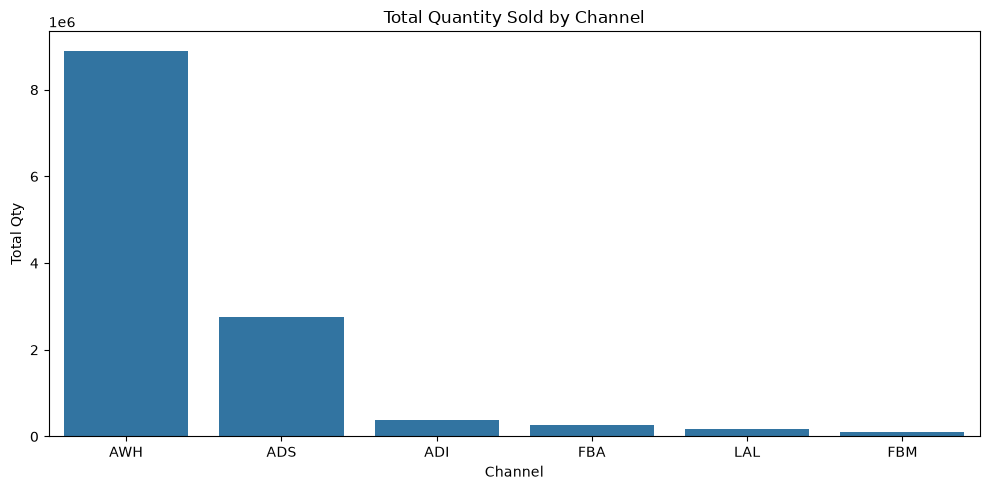

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(data=channel_summary, x="channel", y="total_qty")
plt.title("Total Quantity Sold by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Qty")
plt.tight_layout()
plt.show()

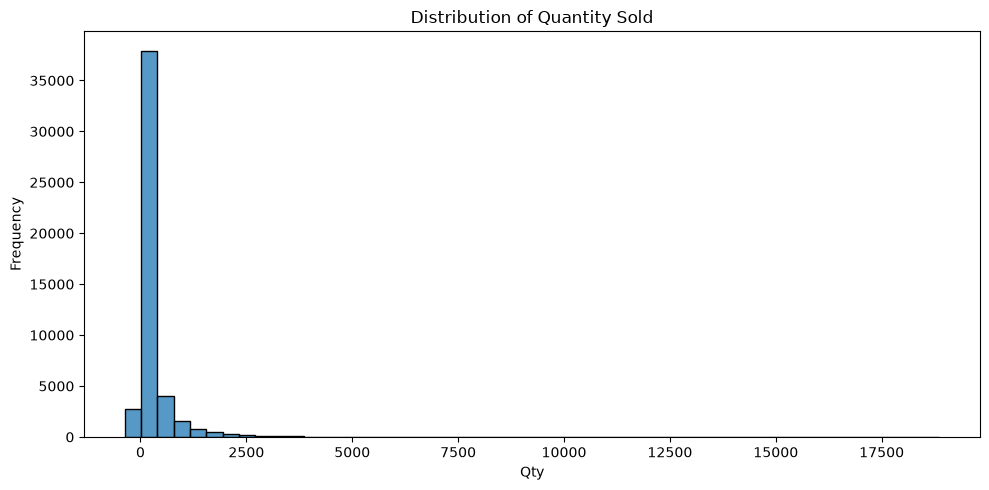

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df["qty"], bins=50)
plt.title("Distribution of Quantity Sold")
plt.xlabel("Qty")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

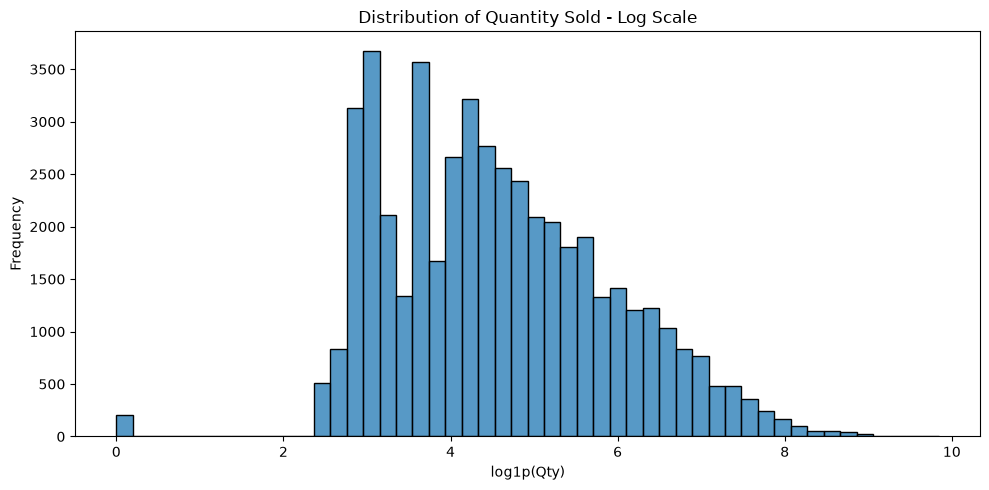

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df[df["qty"] >= 0]["qty"]), bins=50)
plt.title("Distribution of Quantity Sold - Log Scale")
plt.xlabel("log1p(Qty)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

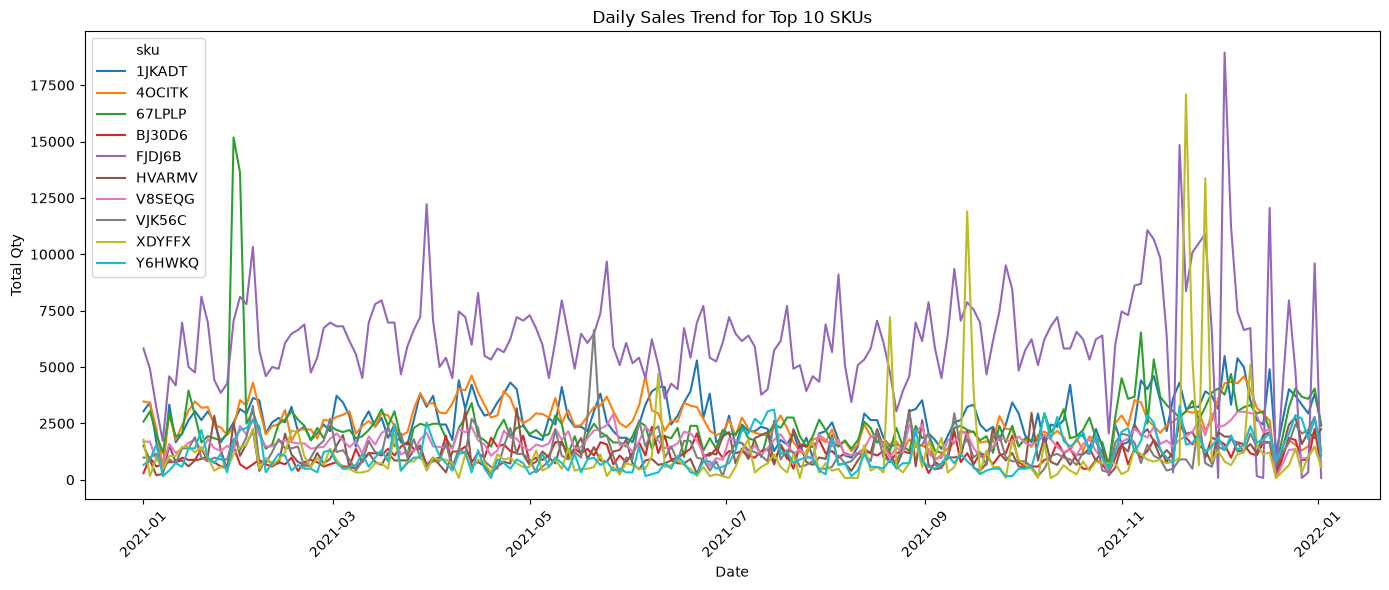

In [24]:
top_10_sku_list = top_10_sku["sku"].tolist()

top_sku_daily = (
    df[df["sku"].isin(top_10_sku_list)]
    .groupby(["shipped_date", "sku"], as_index=False)
    .agg(total_qty=("qty", "sum"))
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=top_sku_daily, x="shipped_date", y="total_qty", hue="sku")
plt.title("Daily Sales Trend for Top 10 SKUs")
plt.xlabel("Date")
plt.ylabel("Total Qty")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
df_eda = df.copy()

# Remove negative quantity rows for sales forecasting analysis
df_eda = df_eda[df_eda["qty"] >= 0].copy()

print(f"Original rows: {len(df):,}")
print(f"Rows after removing negative qty: {len(df_eda):,}")
print(f"Removed rows: {len(df) - len(df_eda):,}")

Original rows: 48,363
Rows after removing negative qty: 48,360
Removed rows: 3


In [26]:
daily_sku_sales = (
    df_eda
    .groupby(["shipped_date", "sku"], as_index=False)
    .agg(
        qty=("qty", "sum"),
        revenue=("revenue", "sum"),
        cost_of_good_sold=("cost of good sold", "sum"),
        moq_order=("MOQ order", "max"),
        channel_count=("channel", "nunique")
    )
)

daily_sku_sales.head()

,shipped_date,sku,qty,revenue,cost_of_good_sold,moq_order,channel_count
0,2021-01-01,089A0E,220,5821.20,2926.00,56460,2
1,2021-01-01,0FKFLA,780,32028.36,13104.00,427545,1
2,2021-01-01,0G8Z4M,85,1307.81,595.00,2516,1
3,2021-01-01,0NFJ14,57,3191.20,2467.78,18734,2
4,2021-01-01,11HSH1,150,7137.90,6209.97,96300,1


In [27]:
print(f"Original cleaned rows: {len(df_eda):,}")
print(f"Daily SKU rows: {len(daily_sku_sales):,}")
print(f"Unique dates: {daily_sku_sales['shipped_date'].nunique():,}")
print(f"Unique SKUs: {daily_sku_sales['sku'].nunique():,}")

daily_sku_sales.info()

Original cleaned rows: 48,360
Daily SKU rows: 42,436
Unique dates: 184
Unique SKUs: 676
<class 'pandas.DataFrame'>
RangeIndex: 42436 entries, 0 to 42435
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   shipped_date       42436 non-null  datetime64[us]
 1   sku                42436 non-null  str           
 2   qty                42436 non-null  int64         
 3   revenue            42436 non-null  float64       
 4   cost_of_good_sold  42436 non-null  float64       
 5   moq_order          42436 non-null  int64         
 6   channel_count      42436 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 2.3 MB


In [28]:
duplicate_daily_sku = daily_sku_sales.duplicated(subset=["shipped_date", "sku"]).sum()
print(f"Duplicate Date-SKU rows: {duplicate_daily_sku:,}")

Duplicate Date-SKU rows: 0


In [29]:
sku_frequency = (
    daily_sku_sales
    .groupby("sku", as_index=False)
    .agg(
        active_days=("shipped_date", "nunique"),
        total_qty=("qty", "sum"),
        avg_qty=("qty", "mean")
    )
    .sort_values("active_days", ascending=False)
)

sku_frequency.head(20)

,sku,active_days,total_qty,avg_qty
650,YCJJRJ,183,46785,255.655738
24,1JKADT,183,489020,2672.240437
645,Y3KMCI,183,88656,484.459016
528,S3JSML,183,41225,225.273224
529,S3KM6D,183,48672,265.967213
591,VJ00JJ,183,204036,1114.950820
592,VJK56C,183,235914,1289.147541
586,V8SEQG,183,303472,1658.316940
32,1WTQ7A,183,40995,224.016393
60,33KM7A,183,68952,376.786885


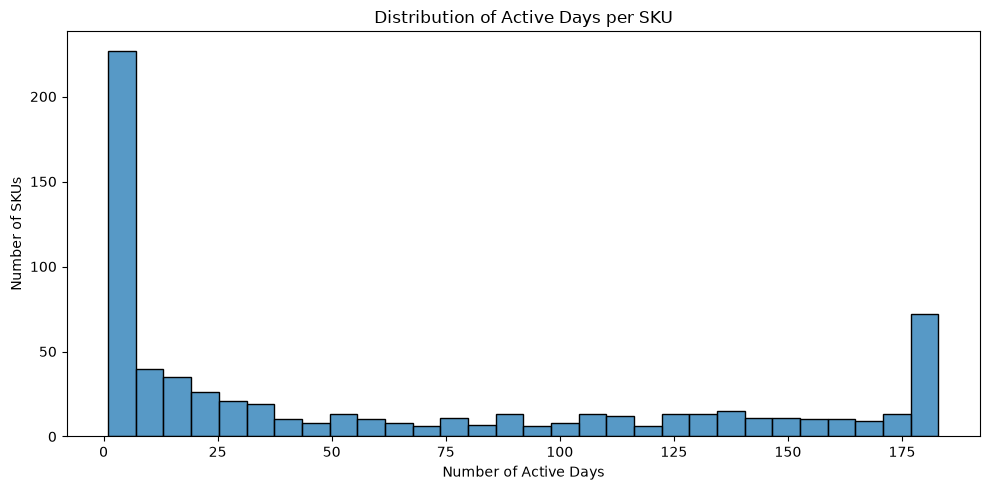

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(sku_frequency["active_days"], bins=30)
plt.title("Distribution of Active Days per SKU")
plt.xlabel("Number of Active Days")
plt.ylabel("Number of SKUs")
plt.tight_layout()
plt.show()

In [31]:
sku_frequency = (
    daily_sku_sales
    .groupby("sku", as_index=False)
    .agg(
        active_days=("shipped_date", "nunique"),
        total_qty=("qty", "sum"),
        avg_qty=("qty", "mean")
    )
    .sort_values(["active_days", "total_qty"], ascending=False)
)

sku_frequency.head(20)

,sku,active_days,total_qty,avg_qty
284,FJDJ6B,183,1135864,6206.907104
24,1JKADT,183,489020,2672.240437
99,4OCITK,183,454305,2482.540984
124,67LPLP,183,445832,2436.240437
586,V8SEQG,183,303472,1658.316940
592,VJK56C,183,235914,1289.147541
591,VJ00JJ,183,204036,1114.950820
129,6HSD4J,183,188699,1031.142077
83,48CE59,183,185172,1011.868852
457,NLDP86,183,171171,935.360656


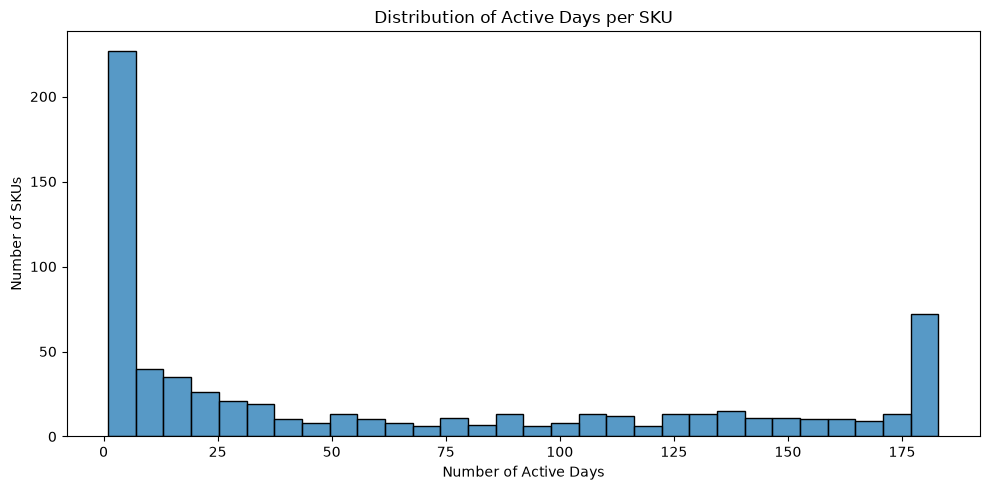

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(sku_frequency["active_days"], bins=30)
plt.title("Distribution of Active Days per SKU")
plt.xlabel("Number of Active Days")
plt.ylabel("Number of SKUs")
plt.tight_layout()
plt.show()

In [33]:
active_day_thresholds = [10, 30, 60, 90, 120, 150, 180]

for threshold in active_day_thresholds:
    count_sku = (sku_frequency["active_days"] >= threshold).sum()
    print(f"SKUs with at least {threshold} active days: {count_sku}")

SKUs with at least 10 active days: 432
SKUs with at least 30 active days: 335
SKUs with at least 60 active days: 271
SKUs with at least 90 active days: 226
SKUs with at least 120 active days: 180
SKUs with at least 150 active days: 120
SKUs with at least 180 active days: 63


In [34]:
MIN_ACTIVE_DAYS = 120

eligible_skus = sku_frequency.loc[
    sku_frequency["active_days"] >= MIN_ACTIVE_DAYS, 
    "sku"
].tolist()

print(f"Number of eligible SKUs: {len(eligible_skus)}")

Number of eligible SKUs: 180


In [35]:
modeling_data = daily_sku_sales[
    daily_sku_sales["sku"].isin(eligible_skus)
].copy()

modeling_data = modeling_data.sort_values(["sku", "shipped_date"]).reset_index(drop=True)

print(f"Modeling data rows: {len(modeling_data):,}")
print(f"Unique SKUs: {modeling_data['sku'].nunique():,}")
print(f"Unique dates: {modeling_data['shipped_date'].nunique():,}")

modeling_data.head()

Modeling data rows: 29,004
Unique SKUs: 180
Unique dates: 183


,shipped_date,sku,qty,revenue,cost_of_good_sold,moq_order,channel_count
0,2021-01-01,089A0E,220,5821.2,2926.0,56460,2
1,2021-01-03,089A0E,140,3704.4,2156.0,56460,1
2,2021-01-05,089A0E,150,3969.0,2310.0,56460,1
3,2021-01-09,089A0E,190,5027.4,2926.0,56460,1
4,2021-01-11,089A0E,60,1587.6,924.0,56460,1


In [36]:
modeling_sku_check = (
    modeling_data
    .groupby("sku", as_index=False)
    .agg(
        active_days=("shipped_date", "nunique"),
        total_qty=("qty", "sum"),
        avg_qty=("qty", "mean")
    )
    .sort_values("active_days")
)

modeling_sku_check.head()

,sku,active_days,total_qty,avg_qty
33,5JT2J6,121,5976,49.388430
138,SHZ5Y2,121,116952,966.545455
13,3B92VR,122,7201,59.024590
0,089A0E,123,18820,153.008130
85,HHB8AA,123,36146,293.869919


In [37]:
PROCESSED_DATA_DIR = Path("../01_data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

processed_path = PROCESSED_DATA_DIR / "daily_sku_sales_processed.csv"
modeling_data.to_csv(processed_path, index=False)

print(f"Processed modeling dataset saved to: {processed_path}")

Processed modeling dataset saved to: ..\01_data\processed\daily_sku_sales_processed.csv


In [38]:
pd.read_csv(processed_path).head()

,shipped_date,sku,qty,revenue,cost_of_good_sold,moq_order,channel_count
0,2021-01-01,089A0E,220,5821.2,2926.0,56460,2
1,2021-01-03,089A0E,140,3704.4,2156.0,56460,1
2,2021-01-05,089A0E,150,3969.0,2310.0,56460,1
3,2021-01-09,089A0E,190,5027.4,2926.0,56460,1
4,2021-01-11,089A0E,60,1587.6,924.0,56460,1


In [39]:
eda_summary = {
    "raw_rows": len(df),
    "raw_columns": df.shape[1],
    "date_min": df["shipped_date"].min(),
    "date_max": df["shipped_date"].max(),
    "raw_unique_dates": df["shipped_date"].nunique(),
    "raw_unique_skus": df["sku"].nunique(),
    "negative_qty_rows_removed": len(df) - len(df_eda),
    "daily_sku_rows": len(daily_sku_sales),
    "eligible_sku_threshold_active_days": MIN_ACTIVE_DAYS,
    "eligible_skus": len(eligible_skus),
    "modeling_rows": len(modeling_data),
    "modeling_unique_dates": modeling_data["shipped_date"].nunique(),
    "modeling_unique_skus": modeling_data["sku"].nunique()
}

eda_summary_df = pd.DataFrame([eda_summary])
eda_summary_df

,raw_rows,raw_columns,date_min,date_max,raw_unique_dates,raw_unique_skus,negative_qty_rows_removed,daily_sku_rows,eligible_sku_threshold_active_days,eligible_skus,modeling_rows,modeling_unique_dates,modeling_unique_skus
0,48363,7,2021-01-01,2022-01-02,184,676,3,42436,120,180,29004,183,180


In [40]:
OUTPUT_RESULTS_DIR = Path("../05_outputs/model_results")
OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

eda_summary_path = OUTPUT_RESULTS_DIR / "eda_summary.csv"
eda_summary_df.to_csv(eda_summary_path, index=False)

print(f"EDA summary saved to: {eda_summary_path}")

EDA summary saved to: ..\05_outputs\model_results\eda_summary.csv
